In [3]:
import os 
from pathlib import Path
import numpy as np
import tqdm 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# # make the dirs
# Path('predictions').mkdir(exist_ok=True)
# Path('uncertainty_maps').mkdir(exist_ok=True)

# # move all the ones with uncertainty in the name to the uncertainty_maps folder
# for file in os.listdir(base_dir):
#     if file.endswith('.nii.gz'):
#         if 'uncertainty' in file:
#             os.rename(file, os.path.join('uncertainty_maps', file))
#         else:
#             os.rename(file, os.path.join('predictions', file))

In [5]:
import torch 

print(torch.__version__)

2.12.0.dev20260408+cu128


In [6]:
# import os
# import numpy as np
# import json
# import nibabel as nib
# import matplotlib.pyplot as plt
# from pathlib import Path

# BASEDIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_10_ensemble_results/train_predictions/'

# label_files = [f for f in os.listdir(BASEDIR) if f.endswith('5.nii.gz')]

# # import the nibabel things
# os.chdir(BASEDIR)
# Path('predictions').mkdir(exist_ok=True)
# Path('uncertainty_maps').mkdir(exist_ok=True)

# # move all the ones with uncertainty in the name to the uncertainty_maps folder
# for file in os.listdir(BASEDIR):
#     if file.endswith('.nii.gz'):
#         if 'uncertainty' in file:
#             os.rename(file, os.path.join('uncertainty_maps', file))
#         else:
#             os.rename(file, os.path.join('predictions', file))

In [17]:
import os
import numpy as np
import json
BASEDIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0_10/train_tta_predicted_bad_subset/'

# # Now all paths are SHORT
# os.chdir(BASEDIR)
# UNCERTAINTY_MAPS_DIR = './train_uncertainty_maps'
# # UNCERTAINTY_MAPS_DIR_RAW = './train_uncertainty_maps_raw'
# PREDICTED_LABELS_DIR = './train_predictions'
# SUMMARY_JSON_DIR     = './train_predictions/summary.json'
# TRUE_LABELS_DIR      = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr'
# SAVE_DIR             = '/lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples/'

# BASEDIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/'
# BASEDIR += 'fold_10_ens_global_comb_train_results/'
# Now all paths are SHORT
os.chdir(BASEDIR)
UNCERTAINTY_MAPS_DIR = './uncertainty_maps_global_norm'
UNCERTAINTY_MAPS_DIR_RAW = './uncertainty_maps_global_norm'
PREDICTED_LABELS_DIR = './train_predictions'
SUMMARY_JSON_DIR     = './train_predictions/summary.json'
TRUE_LABELS_DIR      = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/labelsTr'
SAVE_DIR             = BASEDIR

# Verify
print("UNCERTAINTY_MAPS_DIR exists:", os.path.exists(UNCERTAINTY_MAPS_DIR_RAW))
print("PREDICTED_LABELS_DIR exists:", os.path.exists(PREDICTED_LABELS_DIR))
print("SUMMARY_JSON_DIR exists:    ", os.path.exists(SUMMARY_JSON_DIR))
print("TRUE_LABELS_DIR exists:     ", os.path.exists(TRUE_LABELS_DIR))
print("SAVE_DIR exists:            ", os.path.exists(SAVE_DIR))

# Load summary JSON
with open(SUMMARY_JSON_DIR, 'r') as f:
    summary_json = json.load(f)

per_cases = summary_json['metric_per_case']

# Find uncertainty map files
X = "_uncertainty"
files_with_prefix = [
    f for f in os.listdir(UNCERTAINTY_MAPS_DIR)
    if f.endswith(f'{X}.nii.gz')
]
file_names_in_true = [f.replace(X, '').strip() for f in files_with_prefix]

file_dices = []
    
print("\nFiles found:", len(files_with_prefix))
print(files_with_prefix[:5])
print(file_names_in_true[:5])


pickle_file_path = os.path.join(UNCERTAINTY_MAPS_DIR, 'global_uncertainty_stats.pkl')
# global_stats = np.load(pickle_file_path, allow_pickle=True)

UNCERTAINTY_MAPS_DIR exists: True
PREDICTED_LABELS_DIR exists: True
SUMMARY_JSON_DIR exists:     True
TRUE_LABELS_DIR exists:      True
SAVE_DIR exists:             True

Files found: 940
['fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerper  primaer mit KM-27681_uncertainty_uncertainty.nii.gz', 'fdg_249c02c01c_03-06-2003-NA-PET-CT Ganzkoerper  primaer mit KM-65884_uncertainty_uncertainty.nii.gz', 'fdg_ae46202abb_02-28-2003-NA-PET-CT Ganzkoerper  primaer mit KM-77748_uncertainty_uncertainty.nii.gz', 'psma_7fd33c03d8712a0b_2018-02-16_uncertainty_uncertainty.nii.gz', 'fdg_b4247b8ecd_05-27-2007-NA-PET-CT Ganzkoerper  primaer mit KM-57904_uncertainty_uncertainty.nii.gz']
['fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerper  primaer mit KM-27681.nii.gz', 'fdg_249c02c01c_03-06-2003-NA-PET-CT Ganzkoerper  primaer mit KM-65884.nii.gz', 'fdg_ae46202abb_02-28-2003-NA-PET-CT Ganzkoerper  primaer mit KM-77748.nii.gz', 'psma_7fd33c03d8712a0b_2018-02-16.nii.gz', 'fdg_b4247b8ecd_05-27-2007-NA-PET-CT Ganzkoe

In [22]:
import nibabel as nib

def get_uncertainty_map(case, unc_dir=UNCERTAINTY_MAPS_DIR, binned = False): 
    uncertainty_map_path = os.path.join(unc_dir, case)
    uncertainty_map = nib.load((uncertainty_map_path)).get_fdata()
    # get the sum of the uncertainty map
    if binned:
        uncertainty_map = np.digitize(uncertainty_map, bins=20)
    return uncertainty_map

def get_predicted_label(case, pred_dir=PREDICTED_LABELS_DIR):
    predicted_label_path = os.path.join(pred_dir, case.replace('_total_uncertainty', ''))
    predicted_label = nib.load((predicted_label_path)).get_fdata()
    # get the sum of the predicted label
    return predicted_label

def get_dice_for_case(case, per_cases=per_cases):
    for item in per_cases:
        if case.replace('_total_uncertainty', '') in item['prediction_file']:
            return item['metrics']['1']['Dice']
    return None




In [23]:
import tqdm 

MODE  = 'TTA' # or ENS

def process_uncertainty_map(uncertainty_map, filename, predicted_label=None, bin_size=0.05, max_val=1.0):
    """
    Takes an uncertainty map, bins it, and returns statistics.
    
    Parameters:
    -----------
    uncertainty_map : np.ndarray
        The uncertainty map
    filename : str
        Name of the file
    predicted_label : np.ndarray, optional
        Binary mask of predicted pixels (predicted > 0). If provided, 
        calculates uncertainty statistics for predicted vs non-predicted regions.
    bin_size : float
        Size of bins for histogram
    max_val : float
        Maximum value for histogram
    
    Returns:
    --------
    tuple : (binned_df, summary_df)
        - binned_df: DataFrame with histogram bins
        - summary_df: DataFrame with aggregate statistics
    """
    values = uncertainty_map.flatten()
    bin_edges = np.arange(0, max_val + bin_size, bin_size)
    counts, edges = np.histogram(values, bins=bin_edges)
    bin_labels = [f"{edges[i]:.2f}-{edges[i+1]:.2f}" for i in range(len(edges)-1)]    
    
    binned_df = pd.DataFrame({
        'bin': bin_labels,
        'count': counts,
        'filename': filename
    })
    
    # Calculate summary statistics
    summary_stats = {
        'filename': filename,
        'average_uncertainty': float(np.mean(values)),
        'average_uncertainty_above_0': float(np.mean(values[values > 0])) if np.any(values > 0) else np.nan,
    }
    
    # Add predicted/non-predicted statistics if mask is provided
    if predicted_label is not None:
        predicted_mask = predicted_label > 0
        uncertainty_predicted = values[predicted_mask.flatten()]
        uncertainty_non_predicted = values[~predicted_mask.flatten()]
        
        summary_stats['average_uncertainty_predicted'] = float(np.mean(uncertainty_predicted)) if uncertainty_predicted.size > 0 else np.nan
        summary_stats['average_uncertainty_non_predicted'] = float(np.mean(uncertainty_non_predicted)) if uncertainty_non_predicted.size > 0 else np.nan
    else:
        print(f"Warning: No predicted label provided for {filename}. Skipping predicted/non-predicted statistics.")
        summary_stats['average_uncertainty_predicted'] = np.nan
        summary_stats['average_uncertainty_non_predicted'] = np.nan
    
    summary_df = pd.DataFrame([summary_stats])
    
    return binned_df, summary_df

    
# Usage - loop over your files
dfs = []
summary_dfs = []


MODE = 'TTA' # or 'ENS'
uncertainty_dir = UNCERTAINTY_MAPS_DIR # UNCERTAINTY_MAPS_DIR --- IGNORE ---
if MODE == 'TTA':
    X = '_uncertainty_uncertainty'
    file_names_in_true = [f.replace(X, '').strip() for f in files_with_prefix]
else: 
    X = '_total_uncertainty'
    file_names_in_true = [f.replace(X, '').strip() for f in files_with_prefix if f.endswith(f'{X}.nii.gz')]

# Remove duplicates
file_names_in_true = list(set(file_names_in_true))

print(len(file_names_in_true[:15]))


for filepath in tqdm.tqdm(file_names_in_true):  # Process first 10a files as an example
    # if the filepath is in the uncertainty dir then get the uncertainty map, else skip
    if not os.path.exists(os.path.join(uncertainty_dir, filepath.replace('.nii.gz', f'{X}.nii.gz'))):
        print(f"Warning: Uncertainty map for {filepath} not found in {uncertainty_dir}. Skipping.")
        print(f"Expected path: {os.path.join(uncertainty_dir, filepath.replace('.nii.gz', f'{X}.nii.gz'))}")
        continue
    uncertainty_map = get_uncertainty_map(filepath.replace('.nii.gz', f'{X}.nii.gz'), uncertainty_dir, binned=False)
    predicted_map = get_predicted_label(filepath, PREDICTED_LABELS_DIR)
    # dice_for_case = get_dice_for_case(filepath, file)
    # print the sum of the uncertainty map and predicted map for debugging
    # print(f"Sum of uncertainty map for {filepath}: {np.sum(uncertainty_map)}")
    # print(f"Sum of predicted map for {filepath}: {np.sum(predicted_map)}")
    
    filename = os.path.basename(filepath)
    binned_df, summary_df = process_uncertainty_map(uncertainty_map, filename, predicted_label=predicted_map)
    # add the dice
    # summary_df['dice'] = dice_for_case
    # binned_df['dice'] = dice_for_case
    dfs.append(binned_df)
    summary_dfs.append(summary_df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_summary_df = pd.concat(summary_dfs, ignore_index=True)

import datetime
# get the date and time 
now = datetime.datetime.now()
now_str = now.strftime("%Y_%m_%d_%H%M%S")


combined_df.to_csv(os.path.join(SAVE_DIR, 'global_uncertainty_stats_fixed' + now_str + '.csv'), index=False)
combined_summary_df.to_csv(os.path.join(SAVE_DIR, 'global_uncertainty_summary_stats_fixed' + now_str + '.csv'), index=False)

15


100%|██████████| 940/940 [20:58<00:00,  1.34s/it]


In [ ]:
import pandas as pd
# bad_files = pd.read_csv('bad_uncertainty_files.csv')

In [1]:
# import glob
import pandas as pd
from glob import glob
import os
SAVE_DIR             = '/lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples'

csv_files = glob(os.path.join(SAVE_DIR, 'binned*.csv'))
print(len(csv_files))
combined_df = pd.read_csv(csv_files[0])


def get_dice_for_case(case_name, summary_json):
    for case in summary_json['metric_per_case']: 
        curr_dice = (case['metrics']['1']['Dice'])
        curr_fname = os.path.basename(case['prediction_file']).replace('.nii.gz', '')
        case_name = case_name.replace('.nii.gz', '')

        if curr_fname == case_name:
            return curr_dice

def get_TP_FN_for_case(case_name, summary_json):
    for case in summary_json['metric_per_case']: 
        curr_TP = (case['metrics']['1']['TP'])
        curr_FN = (case['metrics']['1']['FN'])
        curr_fname = os.path.basename(case['prediction_file']).replace('.nii.gz', '')
        case_name = case_name.replace('.nii.gz', '')
        if curr_fname == case_name.replace('nii.gz', ''):
            return curr_TP, curr_FN



2


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import os

# Assuming your dataframe has these columns:
# col0: index, col1: uncertainty_bin, col2: voxel_count, col3: case_name, col4: dice
SAVE_DIR             = '/lab/B/BhattacharyaI/Results/Biratal/Uncertainty_Examples'

csv_files = glob(os.path.join(SAVE_DIR, 'TTA*binned*.csv'))
combined_df = pd.read_csv(csv_files[0])
print(len(csv_files))
summary_files = glob(os.path.join(SAVE_DIR, 'TTA*summary*.csv'))
combined_summary_df = pd.read_csv(summary_files[0])

# First, let's name the columns properly
combined_df = combined_df.loc[:, ['bin', 'count', 'filename']]
combined_df.columns = ['uncertainty_bin', 'voxel_count', 'case_name']

# Define "high uncertainty" threshold - e.g., uncertainty > 0.5
HIGH_UNCERTAINTY_THRESHOLD = 0.5

# Extract the lower bound of each uncertainty bin
combined_df['uncertainty_lower'] = combined_df['uncertainty_bin'].str.split('-').str[0].astype(float)
filtered_combined_df = combined_df[combined_df['uncertainty_lower'] >= 0.1]


# Calculate total voxels and high uncertainty voxels per case
total_voxels = filtered_combined_df.groupby('case_name')['voxel_count'].sum().reset_index()
total_voxels.columns = ['case_name', 'total_voxels']

print(filtered_combined_df.head())

2
  uncertainty_bin  voxel_count  \
2       0.10-0.15          272   
3       0.15-0.20          193   
4       0.20-0.25          152   
5       0.25-0.30          141   
6       0.30-0.35          132   

                                           case_name  uncertainty_lower  
2  fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...               0.10  
3  fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...               0.15  
4  fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...               0.20  
5  fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...               0.25  
6  fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...               0.30  


In [27]:
# combined summary df where predicted uncertainty is 0 
bad_uncertainty_files = combined_summary_df[combined_summary_df['average_uncertainty'] == 0]
bad_uncertainty_files.to_csv('bad_uncertainty_files.csv', index=False)


In [26]:
# for file in bad_uncertainty files 
# get the OG dir for them and make thm 
ORIGNAL_TRAIN_LINK_DIR = '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/imagesTr'
BAD_FILES_SUBSET_DIR = '/lab/B/BhattacharyaI/Results/Biratal/nnUNet_data/nnUNet_results/Dataset999_AutoPet/bad_files_subset'

os.makedirs(BAD_FILES_SUBSET_DIR, exist_ok=True)

print(os.path.exists(ORIGNAL_TRAIN_LINK_DIR))
print(os.listdir(ORIGNAL_TRAIN_LINK_DIR))


for file in bad_uncertainty_files['filename']:
    pet_dir = os.path.join(ORIGNAL_TRAIN_LINK_DIR, file.replace('.nii.gz', '_0001.nii.gz'))
    ct_dir = os.path.join(ORIGNAL_TRAIN_LINK_DIR, file.replace('.nii.gz', '_0000.nii.gz'))
    print(pet_dir)
    print(os.path.exists(pet_dir))
    print(ct_dir)
    print(os.path.exists(ct_dir))
    
    # if both exist, symlink them to the BAD_FILES_SUBSET_DIR
    if os.path.exists(pet_dir) and os.path.exists(ct_dir):
        os.symlink(pet_dir, os.path.join(BAD_FILES_SUBSET_DIR, os.path.basename(pet_dir)))
        os.symlink(ct_dir, os.path.join(BAD_FILES_SUBSET_DIR, os.path.basename(ct_dir)))
    break

True
['psma_7e76841f3c9623c0_2016-01-23_0001.nii.gz', 'fdg_605369e88d_09-15-2002-NA-PET-CT Ganzkoerper  primaer mit KM-20636_0001.nii.gz', 'fdg_6efefcb92a_03-26-2005-NA-PET-CT Ganzkoerper  primaer mit KM-24165_0001.nii.gz', 'fdg_8b40e356dc_06-18-2007-NA-PET-CT Ganzkoerper nativ u. mit KM-04076_0000.nii.gz', 'fdg_d6a48a629d_03-06-2003-NA-PET-CT Ganzkoerper  primaer mit KM-61967_0000.nii.gz', 'fdg_64aff75516_10-16-2005-NA-PET-CT Ganzkoerper  primaer mit KM-66236_0001.nii.gz', 'psma_9abd0bb6d4259d4e_2015-10-22_0001.nii.gz', 'fdg_2d70838805_04-30-2007-NA-PET-CT Ganzkoerper  primaer mit KM-77347_0001.nii.gz', 'fdg_176bdc5388_06-22-2006-NA-PET-CT Ganzkoerper  primaer mit KM-71560_0000.nii.gz', 'fdg_87afc291ec_07-20-2003-NA-PET-CT Ganzkoerper nativ-60370_0000.nii.gz', 'fdg_62a78a061f_08-29-2005-NA-PET-CT Ganzkoerper  primaer mit KM-87956_0001.nii.gz', 'fdg_e09a20d8fc_03-16-2006-NA-PET-CT Ganzkoerper  primaer mit KM-62436_0001.nii.gz', 'fdg_44bf7dc508_07-25-2002-NA-PET-CT Ganzkoerper  primaer 

PermissionError: [WinError 5] Access is denied: '/lab/B/BhattacharyaI/Public_Datasets/Autopet_III_nnunet_raw/Dataset888_AutoPet/imagesTr\\psma_7fd33c03d8712a0b_2018-02-16_0001.nii.gz' -> '/lab/B/BhattacharyaI/Results/Biratal/nnUNet_data/nnUNet_results/Dataset999_AutoPet/bad_files_subset\\psma_7fd33c03d8712a0b_2018-02-16_0001.nii.gz'

In [157]:
print(len(bad_uncertainty_files))
X = '_uncertainty_uncertainty' if MODE == 'TTA' else '_total_uncertainty'
for filepath in tqdm.tqdm(bad_uncertainty_files['filename']):  # Process first 10a files as an example
    print(filepath)
    uncertainty_map = get_uncertainty_map(filepath.replace('.nii.gz', f'{X}.nii.gz'), UNCERTAINTY_MAPS_DIR)
    predicted_map = get_predicted_label(filepath, PREDICTED_LABELS_DIR)
    # get the sum of the predicted_map 
    predicted_sum = np.sum(predicted_map)
    print(f"Sum of predicted map: {predicted_sum}")
    print(f"Sum of uncertainty map: {np.sum(uncertainty_map)}")
    # dice_for_case = get_dice_for_case(filepath, per_cases)
    # print if uncertainty map is there
        
    filename = os.path.basename(filepath)
    binned_df, summary_df = process_uncertainty_map(uncertainty_map, filename, predicted_label=predicted_map)
    # add the dice
    # summary_df['dice'] = dice_for_case
    # binned_df['dice'] = dice_for_case
    
    # dfs.append(binned_df)
    # summary_dfs.append(summary_df)

    break

0


0it [00:00, ?it/s]


In [158]:
bad_uncertainty_files.to_csv("bad_uncertainty_files.csv", index=False)

<Axes: >

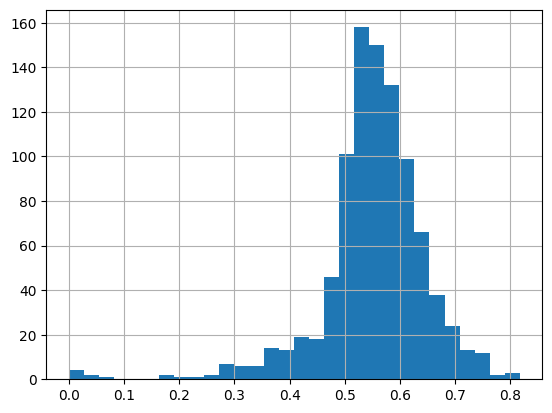

In [159]:
ubs_df.UBS.hist(bins=30)

In [143]:
def compute_ubs_from_bins(case_df, threshold=HIGH_UNCERTAINTY_THRESHOLD, min_bin=0.1):
    """
    min_bin: ignore bins below this (removes zero/near-zero uncertainty voxels
             that dominate the total count)
    """

    # --- Only consider voxels ABOVE the minimum bin (removes zero-uncertainty mass) ---
    nonzero_df = case_df[case_df['uncertainty_lower'] >= min_bin].copy()

    # Normalise against THIS — not the full volume
    total_relevant_voxels = nonzero_df['voxel_count'].sum()

    # High uncertainty bins
    high_unc_df = nonzero_df[nonzero_df['uncertainty_lower'] >= threshold].copy()
    high_unc_voxels = high_unc_df['voxel_count'].sum()

    # Fraction: how much of the NON-ZERO uncertainty mass is HIGH uncertainty
    frac_unc = high_unc_voxels / (total_relevant_voxels + 1e-8)

    # Weighted mean uncertainty using bin midpoint
    if high_unc_voxels > 0:
        high_unc_df['bin_midpoint'] = high_unc_df['uncertainty_lower'] + 0.025
        weighted_mean_unc = (
            (high_unc_df['bin_midpoint'] * high_unc_df['voxel_count']).sum()
            / high_unc_voxels
        )
    else:
        weighted_mean_unc = 0.0

    ubs = frac_unc * weighted_mean_unc

    return pd.Series({
        'total_relevant_voxels': total_relevant_voxels,   # voxels with unc >= 0.1
        'high_unc_voxels':       high_unc_voxels,         # voxels above threshold
        'frac_unc':              frac_unc,                 # fraction of RELEVANT voxels
        'weighted_mean_unc':     weighted_mean_unc,
        'UBS':                   ubs,
    })

HIGH_UNCERTAINTY_THRESHOLD = 0.5    

ubs_df = (
    combined_df
    .groupby('case_name')
    .apply(compute_ubs_from_bins, threshold=HIGH_UNCERTAINTY_THRESHOLD, min_bin=0.1)
    .reset_index()
)

print(ubs_df.sort_values('UBS', ascending=False))

for case in ubs_df.case_name.values: 
    TP, FN  = get_TP_FN_for_case(case, summary_json)
    dice = get_dice_for_case(case, summary_json)
    # add the dice to ubs_df 
    ubs_df.loc[ubs_df['case_name'] == case, 'dice'] = dice

                                             case_name  total_relevant_voxels  \
484  fdg_d325897ff4_07-15-2005-NA-PET-CT Ganzkoerpe...                 1040.0   
135  fdg_41fadf6520_02-27-2003-NA-PET-CT Ganzkoerpe...                 3039.0   
568  fdg_f1501b1f45_03-20-2005-NA-PET-CT Ganzkoerpe...                 9209.0   
393  fdg_b04be2846e_11-15-2004-NA-PET-CT Ganzkoerpe...                 6735.0   
530  fdg_e1a5b05186_02-27-2005-NA-PET-CT Ganzkoerpe...                 6719.0   
..                                                 ...                    ...   
3    fdg_0225325b91_08-22-2005-NA-PET-CT Teilkoerpe...                   14.0   
162  fdg_4a72eeb991_12-23-2005-NA-PET-CT Ganzkoerpe...                   42.0   
743  psma_738bc5d9946240f3_2014-11-03_total_uncerta...                    0.0   
429  fdg_bfd89440db_03-11-2007-NA-PET-CT Ganzkoerpe...                    0.0   
205  fdg_5e339b2ecf_05-27-2006-NA-PET-CT Ganzkoerpe...                   12.0   

     high_unc_voxels  frac_

C:\Users\BhattacharyaLab\AppData\Local\Temp\ipykernel_10572\3829071618.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df


TypeError: cannot unpack non-iterable NoneType object

In [31]:
import json 
SPLITS_DIR        = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_AutoPet/splits_final.json'
with open(SPLITS_DIR, 'r') as f:
    splits = json.load(f)
len(splits[0]['train'])

103

In [32]:
import pandas as pd

active_learning_labells_1 = pd.read_csv('../dinov2/ranked_top_1_percent_cases.csv')
active_learning_labells_5 = pd.read_csv('../dinov2/ranked_top_5_percent_cases.csv')

fdg_cases_1 = active_learning_labells_1.loc[active_learning_labells_1['filename'].str.contains('fdg')][['filename']].values
psma_cases_1 = active_learning_labells_1.loc[active_learning_labells_1['filename'].str.contains('psma')][['filename']].values
print("adding the following cases to the training set:")
print(f"FDG cases (1%): {len(fdg_cases_1)}")
print(f"PSMA cases (1%): {len(psma_cases_1)}")

fdg_cases_5 = active_learning_labells_5.loc[active_learning_labells_5['filename'].str.contains('fdg')][['filename']].values
psma_cases_5 = active_learning_labells_5.loc[active_learning_labells_5['filename'].str.contains('psma')][['filename']].values
print(f"FDG cases (5%): {len(fdg_cases_5)}")
print(f"PSMA cases (5%): {len(psma_cases_5)}")


adding the following cases to the training set:
FDG cases (1%): 6
PSMA cases (1%): 4
FDG cases (5%): 33
PSMA cases (5%): 14


In [33]:
new_splits = splits
new_splits = new_splits[:3]
new_splits[2] = splits[6]

In [34]:
new_splits[0]['train'] = splits[0]['train'] + list(fdg_cases_1.flatten()) + list(psma_cases_1.flatten())
new_splits[1]['train'] = splits[1]['train'] + list(fdg_cases_5.flatten()) + list(psma_cases_5.flatten())

In [35]:
# remove new_splits 2 to len 
# print the length of new_splits[2]['train'] and splits[2]['train'] to verify they are the same
print(len(new_splits[0]['train']))
print(len(new_splits[1]['train']))
print(len(new_splits[2]['train']))

# now export new_splits to json
with open('new_splits.json', 'w') as f:
    json.dump(new_splits, f, indent=4)

113
150
1043


In [64]:
# do a histogram of the UBS values
# with 0 UBS
ubs_d_0 = ubs_df[ubs_df['UBS'] == 0]

plt.hist(ubs_d_0['dice'], bins=20)

NameError: name 'ubs_df' is not defined

In [ ]:
ubs_df.loc[ubs_df['case_name'].str.contains('psma_84e8841')]

NameError: name 'ubs_df' is not defined

In [ ]:
# # Define threshold
# HIGH_UNCERTAINTY_THRESHOLD = 0.5
# df = combined_df


# # Extract the lower bound of each uncertainty bin
# df['uncertainty_lower'] = df['uncertainty_bin'].str.split('-').str[0].astype(float)

# # ⚡ Exclude the first bin (0.0 - 0.05)
# df_filtered = df[df['uncertainty_lower'] >= 0]

# # Calculate total voxels (excluding first bin) and high uncertainty voxels per case
# total_voxels = df_filtered.groupby('case_name')['voxel_count'].sum().reset_index()
# total_voxels.columns = ['case_name', 'total_voxels']

# high_unc_voxels = (
#     df_filtered[df_filtered['uncertainty_lower'] >= HIGH_UNCERTAINTY_THRESHOLD]
#     .groupby('case_name')['voxel_count']
#     .sum()
#     .reset_index()
# )
# high_unc_voxels.columns = ['case_name', 'high_unc_voxels']

# # Merge and calculate concentration
# per_case = total_voxels.merge(high_unc_voxels, on='case_name', how='left')
# per_case['high_unc_voxels'] = per_case['high_unc_voxels'].fillna(0)
# per_case['high_unc_concentration'] = per_case['high_unc_voxels'] / per_case['total_voxels']

# # Add dice score
# # dice_per_case = df_filtered.groupby('case_name')['dice'].first().reset_index()
# # per_case = per_case.merge(dice_per_case, on='case_name')

# # Drop rows where dice is NaN
# # per_case = per_case.dropna(subset=['dice'])

# print(per_case.case_name.nunique())


In [ ]:
# # cases where the total_voxels were 0 
# per_case[]
# # cases_zero_total = per_case[per_case['total_voxels'] == 0]
# # for each case in cases_zero_total, get thee dice from the summary_json 


NameError: name 'ubs_df' is not defined

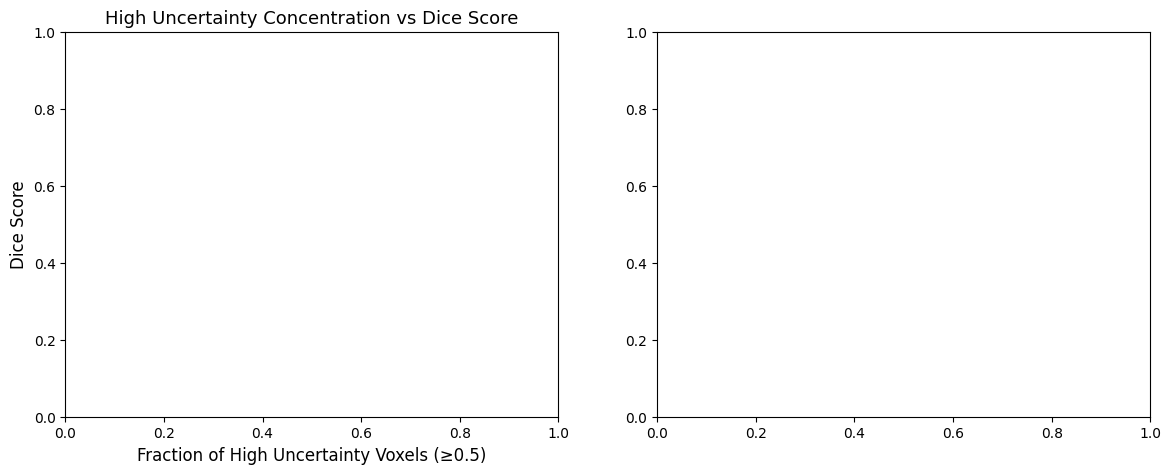

In [1]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot with regression line
ax = axes[0]
# sns.regplot(
#     data=per_case,
#     x='high_unc_concentration',
#     y='dice',
#     scatter_kws={'alpha': 0.6, 'edgecolors': 'white', 's': 60},
#     line_kws={'color': 'red', 'linewidth': 2},
#     ax=ax
# )
ax.set_xlabel(f'Fraction of High Uncertainty Voxels (≥{0.5})', fontsize=12)
ax.set_ylabel('Dice Score', fontsize=12)
ax.set_title('High Uncertainty Concentration vs Dice Score', fontsize=13)


# per_case = per_case.dropna(subset=['dice', 'high_unc_concentration'])

# # corr, p_value = stats.pearsonr(per_case['high_unc_concentration'], per_case['dice'])
# if p_value < 0.001:
#     p_value_str = f" < 0.001"
    
# print(f"Correlation: {corr:.3f}, p-value: {p_value_str}")# get p-value

import scipy.stats as stats

# ax.annotate(f'r = {corr:.3f}\np-value {p_value_str}', xy=(0.05, 0.05), xycoords='axes fraction', fontsize=12,
#             color='red', fontweight='bold')

# 2. Binned box plot
ax = axes[1]

# Get the actual bin edges so we can show ranges in labels
ubs_df['unc_quartile'], bins = pd.qcut(
    ubs_df['UBS'], q=6, retbins=True, duplicates='drop'
)

# Build rich labels: "Q1\n[0.00-0.12]\n(n=42)"
quartile_counts = ubs_df['unc_quartile'].value_counts().sort_index()
rich_labels = []
for i, (interval, count) in enumerate(quartile_counts.items()):
    q_name = ['Q0 (Low)', 'Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'][i]
    lo = interval.left
    hi = interval.right
    rich_labels.append(f'{q_name}\n[{lo:.2f} – {hi:.2f}]')

sns.boxplot(
    data=ubs_df,
    x='unc_quartile',
    y='dice',
    order=ubs_df['unc_quartile'].cat.categories,
    palette='coolwarm',
    ax=ax
)
ax.set_xticklabels(rich_labels, fontsize=10)
ax.set_xlabel('High Uncertainty Concentration (Quartiles)', fontsize=12)
ax.set_ylabel('Dice Score', fontsize=12)
ax.set_title('Dice Score by Uncertainty Concentration Quartile', fontsize=13)

# plt.tight_layout()
# plt.savefig('uncertainty_vs_dice.png', dpi=150, bbox_inches='tight')
# plt.show()

In [ ]:
ubs_df

,case_name,total_relevant_voxels,high_unc_voxels,frac_unc,weighted_mean_unc,UBS,unc_quartile
0,fdg_0143bab87a_07-17-2005-NA-PET-CT Ganzkoerpe...,692.0,469.0,0.677746,0.799094,0.541582,"(0.511, 0.751]"
1,fdg_01682f60c3_03-11-2002-NA-PET-CT Ganzkoerpe...,3206.0,2052.0,0.640050,0.765911,0.490221,"(0.445, 0.511]"
2,fdg_0223010e46_09-04-2003-NA-PET-CT Ganzkoerpe...,441.0,379.0,0.859410,0.740303,0.636224,"(0.511, 0.751]"
3,fdg_0225325b91_08-22-2005-NA-PET-CT Teilkoerpe...,22.0,9.0,0.409091,0.602778,0.246591,"(-0.001, 0.445]"
4,fdg_02ba7e20f5_10-12-2001-NA-PET-CT Ganzkoerpe...,682.0,471.0,0.690616,0.768312,0.530609,"(0.511, 0.751]"
...,...,...,...,...,...,...,...
935,psma_fd142797eb926383_2018-03-04.nii.gz,0.0,0.0,0.000000,0.000000,0.000000,"(-0.001, 0.445]"
936,psma_fedc5777fd9687d3_2019-04-29.nii.gz,0.0,0.0,0.000000,0.000000,0.000000,"(-0.001, 0.445]"
937,psma_ffcaa75377465b37_2016-11-14.nii.gz,0.0,0.0,0.000000,0.000000,0.000000,"(-0.001, 0.445]"
938,psma_ffcaa75377465b37_2017-07-20.nii.gz,0.0,0.0,0.000000,0.000000,0.000000,"(-0.001, 0.445]"


In [ ]:
# Extract filenames without extensions for ALL quartiles
import os

all_quartile_dfs = []

for i, category in enumerate(per_case['unc_quartile'].cat.categories):
    q_cases = per_case[per_case['unc_quartile'] == category]
    q_name = ['Q1_Low', 'Q2', 'Q3', 'Q4_High'][i]
    
    filenames = q_cases['case_name'].str.replace('.nii.gz', '')
    
    q_df = pd.DataFrame({
        'filename': filenames,
        'quartile': q_name,
        'high_unc_concentration': q_cases['high_unc_concentration'].values,
    })
    
    # Save individual CSV per quartile
    q_df.to_csv(f'{q_name}_uncertainty_cases.csv', index=False)
    print(f"Saved {len(q_df)} filenames to {q_name}_uncertainty_cases.csv")
    
    all_quartile_dfs.append(q_df)

# Also save one combined CSV with all quartiles
combined_df = pd.concat(all_quartile_dfs, ignore_index=True)
combined_df.to_csv('all_quartiles_uncertainty_cases.csv', index=False)
print(f"\nSaved combined CSV with {len(combined_df)} total cases")
print(combined_df)

Saved 148 filenames to Q1_Low_uncertainty_cases.csv
Saved 148 filenames to Q2_uncertainty_cases.csv
Saved 148 filenames to Q3_uncertainty_cases.csv
Saved 148 filenames to Q4_High_uncertainty_cases.csv

Saved combined CSV with 592 total cases
                                              filename quartile  \
0    fdg_0225325b91_08-22-2005-NA-PET-CT Teilkoerpe...   Q1_Low   
1    fdg_08198c4f0c_11-10-2005-NA-PET-CT Ganzkoerpe...   Q1_Low   
2    fdg_0b98dbe00d_08-11-2002-NA-PET-CT Ganzkoerpe...   Q1_Low   
3    fdg_0beb67c923_07-25-1999-NA-PET-CT Ganzkoerpe...   Q1_Low   
4    fdg_0ea07b421b_10-27-2001-NA-PET-CT Ganzkoerpe...   Q1_Low   
..                                                 ...      ...   
587  fdg_f9c4d4f9ab_03-22-2007-NA-PET-CT Ganzkoerpe...  Q4_High   
588  fdg_f9e0c504af_06-29-2003-NA-PET-CT Ganzkoerpe...  Q4_High   
589  fdg_fc0389a486_05-30-2005-NA-PET-CT Ganzkoerpe...  Q4_High   
590  fdg_fde79b6aa9_08-16-2003-NA-PET-CT Ganzkoerpe...  Q4_High   
591  fdg_ff39795341_0

In [ ]:
per_case['case_name'].iloc[0]

'fdg_01682f60c3_03-11-2002-NA-PET-CT Ganzkoerper  primaer mit KM-03431.nii.gz'

In [ ]:
# I'm gettin nans so drop the nan's from both case

per_case = per_case.dropna(subset=['dice', 'high_unc_concentration'])

corr, p_value = stats.pearsonr(per_case['high_unc_concentration'], per_case['dice'])
print(f"Correlation: {corr:.3f}, p-value: {p_value:.20f}")

Correlation: -0.124, p-value: 0.03316495264564429946


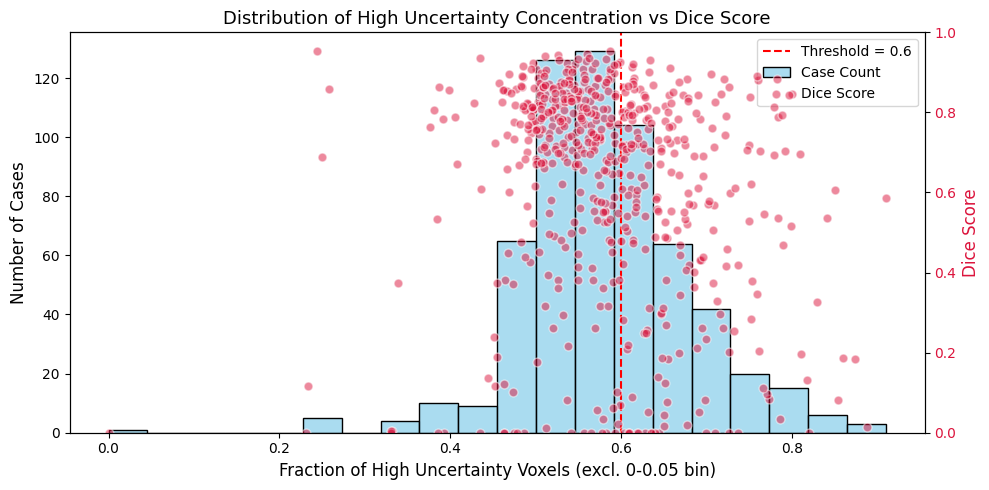

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Histogram on primary axis ---
sns.histplot(
    per_case['high_unc_concentration'],
    bins=20,
    color='skyblue',
    alpha=0.7,
    ax=ax1,
    label='Case Count'
)
ax1.axvline(
    HIGH_UNCERTAINTY_THRESHOLD,
    color='red', linestyle='--', linewidth=1.5,
    label=f'Threshold = {HIGH_UNCERTAINTY_THRESHOLD}'
)
ax1.set_xlabel('Fraction of High Uncertainty Voxels (excl. 0-0.05 bin)', fontsize=12)
ax1.set_ylabel('Number of Cases', fontsize=12)

# --- Scatter dice scores on secondary axis ---
ax2 = ax1.twinx()
ax2.scatter(
    per_case['high_unc_concentration'],
    per_case['dice'],
    color='crimson', alpha=0.5, s=40, edgecolors='white', label='Dice Score'
)
ax2.set_ylabel('Dice Score', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 1)

# --- Combined legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')

plt.title('Distribution of High Uncertainty Concentration vs Dice Score', fontsize=13)
plt.tight_layout()
plt.savefig('uncertainty_histogram_dice.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# select the 

In [ ]:
# avg dice per bin 


In [ ]:
# if concentration of high uncertainty voxels is high, then add it to a list of files 
high_concentration_files = per_case[per_case['high_unc_concentration'] > 0.5]['case_name'].tolist()


In [ ]:
# get concentration of uncertainty.
combined_df 

,uncertainty_bin,voxel_count,case_name,dice,uncertainty_lower
0,0.00-0.05,17235599,psma_838c9340e85ca431_2020-05-23_total_uncerta...,NaN,0.00
1,0.05-0.10,31,psma_838c9340e85ca431_2020-05-23_total_uncerta...,NaN,0.05
2,0.10-0.15,22,psma_838c9340e85ca431_2020-05-23_total_uncerta...,NaN,0.10
3,0.15-0.20,11,psma_838c9340e85ca431_2020-05-23_total_uncerta...,NaN,0.15
4,0.20-0.25,16,psma_838c9340e85ca431_2020-05-23_total_uncerta...,NaN,0.20
...,...,...,...,...,...
18795,0.75-0.80,17,psma_d98ce837bcc6fb20_2016-06-20_total_uncerta...,0.827387,0.75
18796,0.80-0.85,15,psma_d98ce837bcc6fb20_2016-06-20_total_uncerta...,0.827387,0.80
18797,0.85-0.90,12,psma_d98ce837bcc6fb20_2016-06-20_total_uncerta...,0.827387,0.85
18798,0.90-0.95,21,psma_d98ce837bcc6fb20_2016-06-20_total_uncerta...,0.827387,0.90


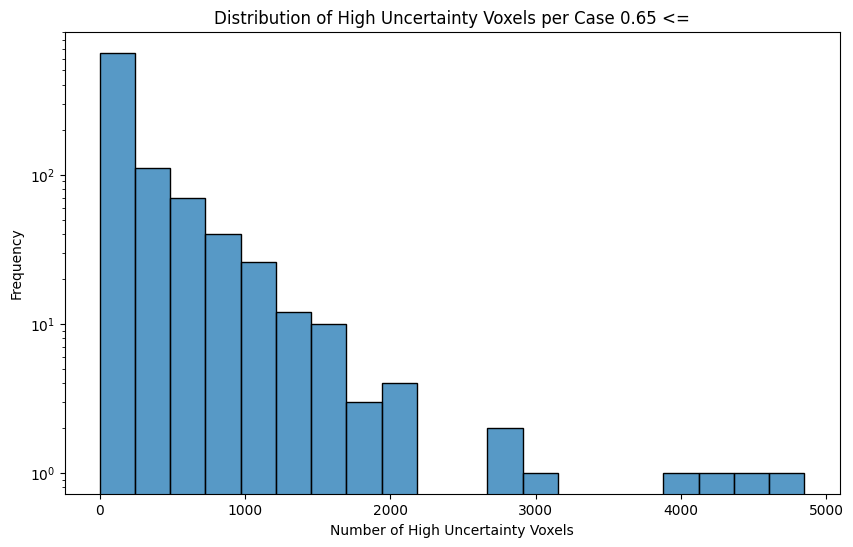

In [ ]:
# from combined_df get the number of voxels that are over 0.65 per case 
high_unc_voxels_df = combined_df[combined_df['uncertainty_bin'].str.startswith('0.65-')]
high_unc_voxels_df = high_unc_voxels_df.groupby('case_name')['voxel_count'].sum().reset_index()
high_unc_voxels_df.rename(columns={'voxel_count': 'high_uncertainty_voxel_count'}, inplace=True)
high_unc_voxels_df

# now do a histogram of the count 
plt.figure(figsize=(10,6))
sns.histplot(high_unc_voxels_df['high_uncertainty_voxel_count'], bins=20)
plt.title('Distribution of High Uncertainty Voxels per Case 0.65 <=')
plt.xlabel('Number of High Uncertainty Voxels')
plt.ylabel('Frequency')
plt.yscale('log')

In [ ]:
# from combined_df get the number of voxels that are over 0.65 per case 
high_unc_voxels_df = combined_df[combined_df['bin'].str.startswith('0.65-')]
high_unc_voxels_df = high_unc_voxels_df.groupby('filename')['count'].sum().reset_index()
high_unc_voxels_df.rename(columns={'count': 'high_uncertainty_voxel_count'}, inplace=True)
high_unc_voxels_df

# now do a histogram of the count 
plt.figure(figsize=(10,6))
sns.histplot(high_unc_voxels_df['high_uncertainty_voxel_count'], bins=20, kde=True)
plt.title('Distribution of High Uncertainty Voxels per Case')
plt.xlabel('Number of High Uncertainty Voxels')
plt.ylabel('Frequency')
plt.yscale('log')

KeyError: 'bin'

In [ ]:
# import numpy as np
# import tqdm 
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# def process_uncertainty_map_averages(uncertainty_map, filename, predicted_label=None, bin_size=0.05, max_val=1.0):
#     """
#     Takes an uncertainty map, bins it, and returns statistics.
    
#     Parameters:
#     -----------
#     uncertainty_map : np.ndarray
#         The uncertainty map
#     filename : str
#         Name of the file
#     predicted_label : np.ndarray, optional
#         Binary mask of predicted pixels (predicted > 0). If provided, 
#         calculates uncertainty statistics for predicted vs non-predicted regions.
#     bin_size : float
#         Size of bins for histogram
#     max_val : float
#         Maximum value for histogram
    
#     Returns:
#     --------
#     tuple : (binned_df, summary_df)
#         - binned_df: DataFrame with histogram bins
#         - summary_df: DataFrame with aggregate statistics
#     """
#     values = uncertainty_map.flatten()
#     bin_edges = np.arange(0, max_val + bin_size, bin_size)
#     counts, edges = np.histogram(values, bins=bin_edges)
#     bin_labels = [f"{edges[i]:.2f}-{edges[i+1]:.2f}" for i in range(len(edges)-1)]    
    
#     binned_df = pd.DataFrame({
#         'bin': bin_labels,
#         'count': counts,
#         'filename': filename
#     })
    
#     # Calculate summary statistics
#     summary_stats = {
#         'filename': filename,
#         'average_uncertainty': float(np.mean(values)),
#         'average_uncertainty_above_0': float(np.mean(values[values > 0])) if np.any(values > 0) else np.nan,
#     }
    
#     # Add predicted/non-predicted statistics if mask is provided
#     if predicted_label is not None:
#         predicted_mask = predicted_label > 0
#         uncertainty_predicted = values[predicted_mask.flatten()]
#         uncertainty_non_predicted = values[~predicted_mask.flatten()]
        
#         summary_stats['average_uncertainty_predicted'] = float(np.mean(uncertainty_predicted)) if uncertainty_predicted.size > 0 else np.nan
#         summary_stats['average_uncertainty_non_predicted'] = float(np.mean(uncertainty_non_predicted)) if uncertainty_non_predicted.size > 0 else np.nan
#     else:
#         summary_stats['average_uncertainty_predicted'] = np.nan
#         summary_stats['average_uncertainty_non_predicted'] = np.nan
    
#     summary_df = pd.DataFrame([summary_stats])
    
#     return binned_df, summary_df

    
# # Usage - loop over your files
# dfs = []
# summary_dfs = []
# for filepath in tqdm.tqdm(file_names_in_true):  # Process first 10a files as an example
#     uncertainty_map = get_uncertainty_map(filepath.replace('.nii.gz', '_uncertainty_uncertainty.nii.gz'), UNCERTAINTY_MAPS_DIR)
#     predicted_map = get_predicted_label(filepath, PREDICTED_LABELS_DIR)
#     dice_for_case = get_dice_for_case(filepath, per_cases)
    
#     filename = os.path.basename(filepath)
#     binned_df, summary_df = process_uncertainty_map(uncertainty_map, filename, predicted_label=predicted_map)
#     # add the dice
#     summary_df['dice'] = dice_for_case
#     binned_df['dice'] = dice_for_case
#     dfs.append(binned_df)
#     summary_dfs.append(summary_df)

# combined_df = pd.concat(dfs, ignore_index=True)
# combined_summary_df = pd.concat(summary_dfs, ignore_index=True)


Text(0, 0.5, 'Dice Score')

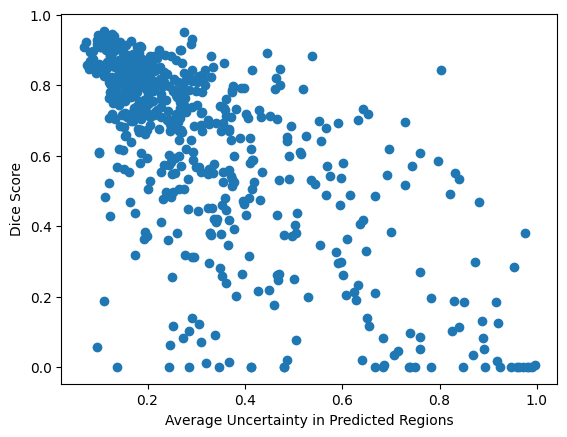

In [ ]:
# plot hi stogram of the combined_summary_df
plt.plot(combined_summary_df['average_uncertainty_predicted'], combined_summary_df['dice'], 'o')
plt.xlabel('Average Uncertainty in Predicted Regions')
plt.ylabel('Dice Score')

In [ ]:
combined_summary_df.columns

NameError: name 'combined_summary_df' is not defined

In [ ]:
combined_summary_df

NameError: name 'combined_summary_df' is not defined

In [ ]:
# # combine all your dataframes first
combined_df.to_csv('binned_combined_df_train_tta.csv', index=False)
combined_summary_df.to_csv('summary_combined_df_train_tta.csv', index=False)

NameError: name 'combined_df' is not defined

In [ ]:
from datetime import time


combined_summary_df['dice'] = combined_summary_df['dice'] * 100

# save combined_df and combined_summary_df


In [ ]:
time

datetime.time

<Figure size 1000x600 with 0 Axes>

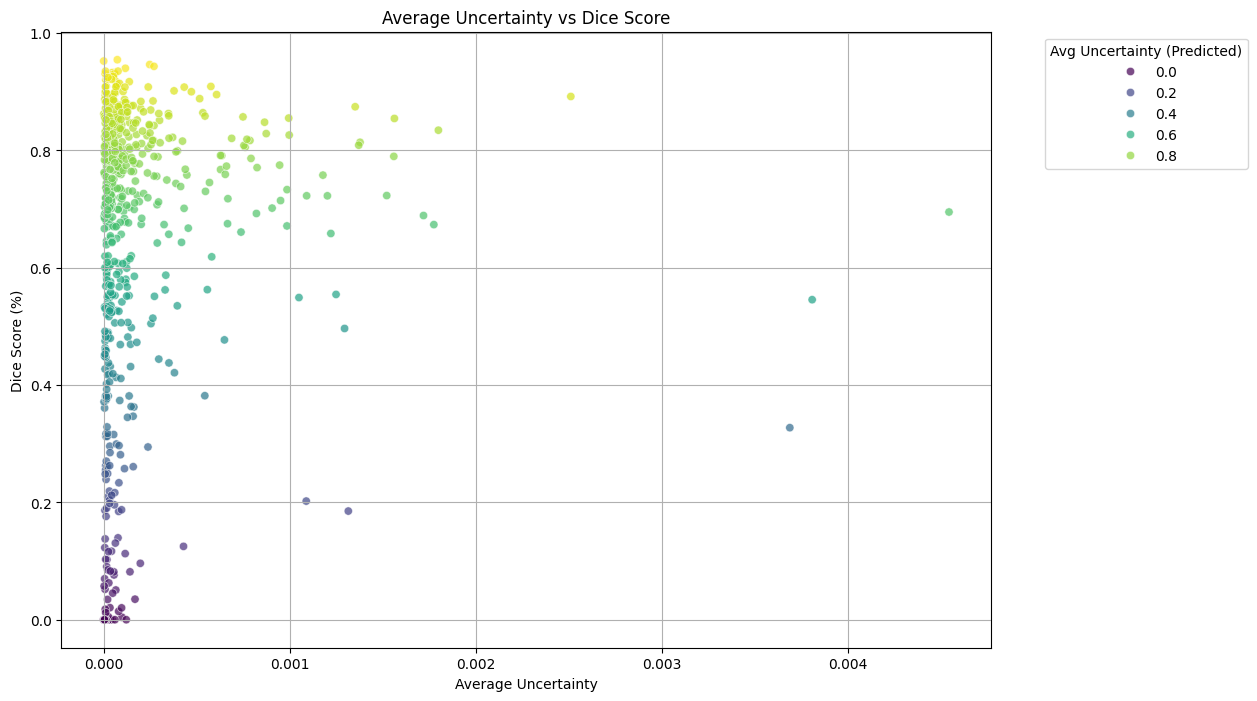

In [ ]:
# do a histplot of the average uncertainty for predicted vs non-predicted regions
plt.figure(figsize=(10, 6))

# do bar plots for the average uncertainty, and for the average_uncertainty_above_0 and color them based on the average dice in that bin. Bins are based on uncertainty

# make bins on uncertainty from this,  like do it for every 0.05 bin, and then plot the average dice in that bin as a color. So x axis is uncertainty bin, y axis is average dice, and color is average uncertainty in that bin. Do this for both predicted and non-predicted regions.

def plot_uncertainty_vs_dice(combined_summary_df):
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=combined_summary_df, 
        x='average_uncertainty', 
        y='dice', 
        hue='dice', 
        palette='viridis', 
        sizes=(20, 200),
        alpha=0.7
    )
    plt.title('Average Uncertainty vs Dice Score')
    plt.xlabel('Average Uncertainty')
    plt.ylabel('Dice Score (%)')
    plt.legend(title='Avg Uncertainty (Predicted)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.show()

plot_uncertainty_vs_dice(combined_summary_df)

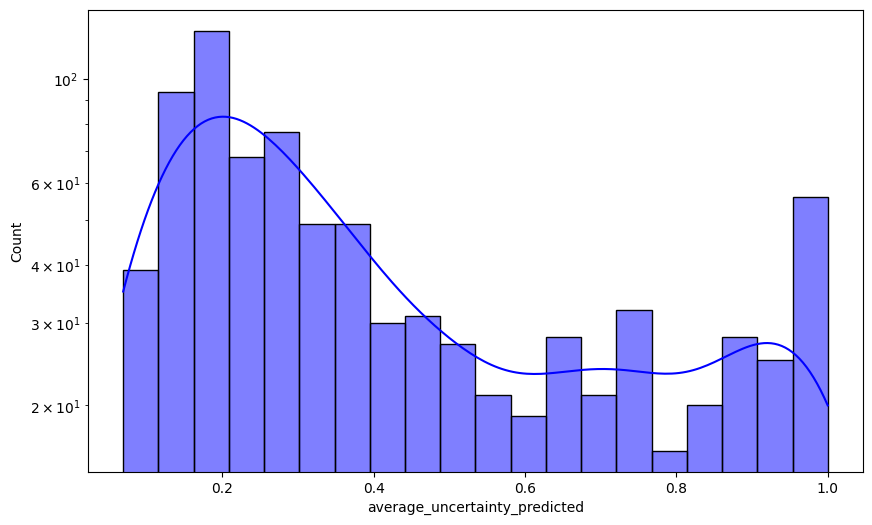

In [ ]:
# do a histplot of the average uncertainty for predicted vs non-predicted regions
plt.figure(figsize=(10, 6))
sns.histplot(data=combined_summary_df, x='average_uncertainty_predicted', color='blue', label='Predicted Regions', kde=True, stat="count", bins=20)
plt.yscale('log')
# do the 

In [ ]:
combined_summary_df

,filename,average_uncertainty,average_uncertainty_above_0,average_uncertainty_predicted,average_uncertainty_non_predicted,dice
0,fdg_8aa48809ea_04-16-2001-NA-PET-CT Ganzkoerpe...,3.623562e-05,0.000419,0.068423,2.128169e-05,82.466889
1,fdg_249c02c01c_03-06-2003-NA-PET-CT Ganzkoerpe...,8.568868e-05,0.001328,0.444418,6.447624e-05,9.875857
2,fdg_ae46202abb_02-28-2003-NA-PET-CT Ganzkoerpe...,4.858113e-06,0.000073,0.136393,3.548087e-06,NaN
3,psma_7fd33c03d8712a0b_2018-02-16.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,57.709038
4,fdg_b4247b8ecd_05-27-2007-NA-PET-CT Ganzkoerpe...,9.865571e-07,0.000013,NaN,9.865571e-07,NaN
...,...,...,...,...,...,...
935,psma_ee0d631fa63961f2_2019-11-08.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,45.106383
936,psma_7e25beff54698eb8_2021-02-06.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,55.452942
937,fdg_e4712dc58c_02-12-1999-NA-PET-CT Ganzkoerpe...,1.312496e-05,0.000114,0.335285,7.327031e-06,26.490464
938,psma_209536ec8c0b1d5e_2019-11-04.nii.gz,0.000000e+00,NaN,0.000000,0.000000e+00,77.722772


In [ ]:
# get a cumulative count for each bin as well 
cumilative_df = combined_df.groupby('bin')['count'].sum().reset_index()
cumilative_df

,bin,count
0,0.00-0.05,38771308712
1,0.05-0.10,489776
2,0.10-0.15,293439
3,0.15-0.20,217465
4,0.20-0.25,177291
5,0.25-0.30,153329
6,0.30-0.35,140302
7,0.35-0.40,132265
8,0.40-0.45,128751
9,0.45-0.50,129828


In [ ]:
# combine all your dataframes first
combined_df = pd.concat(dfs, ignore_index=True)


In [ ]:
files_with_prefix

['fdg_d626611daf_04-03-2003-NA-PET-CT Ganzkoerper  primaer mit KM-63001_epistemic_uncertainty.nii.gz',
 'fdg_86e54ea60a_03-18-2002-NA-PET-CT Ganzkoerper  primaer mit KM-34788_aleatoric_uncertainty.nii.gz',
 'fdg_442a09f90e_03-16-2002-NA-PET-CT Ganzkoerper  primaer mit KM-24290_aleatoric_uncertainty.nii.gz',
 'fdg_527c5afc5d_07-18-2003-NA-PET-CT Ganzkoerper  primaer mit KM-02474_aleatoric_uncertainty.nii.gz',
 'psma_838c9340e85ca431_2020-05-23_total_uncertainty.nii.gz',
 'fdg_05d5a79faf_02-25-2005-NA-PET-CT Ganzkoerper  primaer mit KM-20586_aleatoric_uncertainty.nii.gz',
 'fdg_30c4b7062b_01-18-2001-NA-PET-CT Ganzkoerper  primaer mit KM-73893_epistemic_uncertainty.nii.gz',
 'fdg_3b73c2480a_10-19-2001-NA-PET-CT Ganzkoerper  primaer mit KM-00650_aleatoric_uncertainty.nii.gz',
 'fdg_1b1bdfc35b_10-29-2000-NA-PET-CT Ganzkoerper  primaer mit KM-59300_aleatoric_uncertainty.nii.gz',
 'fdg_3b1c9155f5_01-31-2003-NA-PET-CT Ganzkoerper  primaer mit KM-94971_total_uncertainty.nii.gz',
 'psma_d221fa19

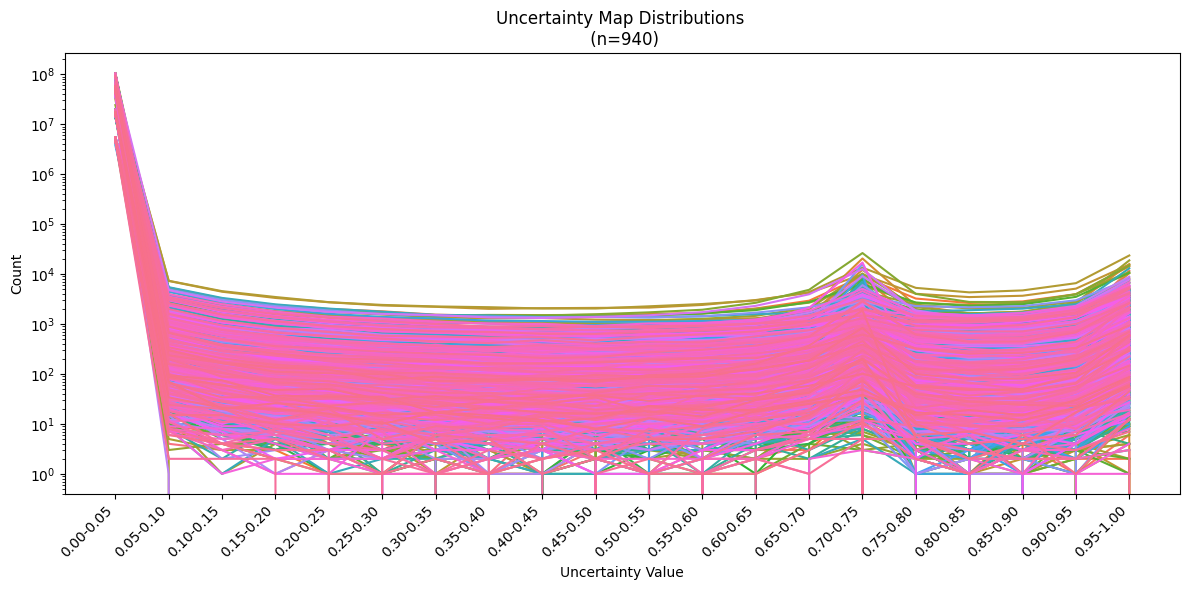

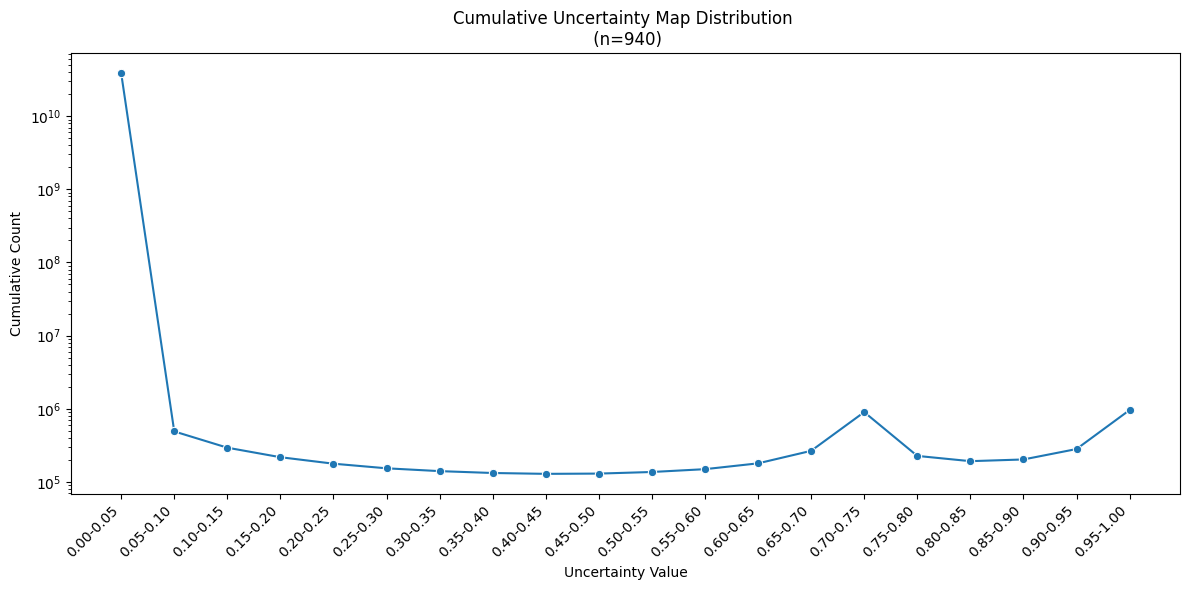

In [ ]:
# combine all your dataframes first
# combined_df = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=combined_df,
    x='bin',
    y='count',
    hue='filename', 
    legend=None
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Uncertainty Value')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Uncertainty Map Distributions \n (n={})'.format(len(file_names_in_true)))
plt.tight_layout()
plt.show()

# also plot the cumulative count
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=cumilative_df,
    x='bin',
    y='count', 
    marker='o'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Uncertainty Value')
plt.ylabel('Cumulative Count')
plt.yscale('log')
plt.title('Cumulative Uncertainty Map Distribution \n (n={})'.format(len(file_names_in_true)))
plt.tight_layout()

# Looking  at the actual uncertainties 